In [ ]:
import os
import sys
import torch as t
import pandas as pd
import numpy as np

PROJECT_ROOT = r"C:\Mestrado\Graph_Pruning\AnyGraph"

os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
sys.argv = ["analysis"]

In [23]:
from model import AnyGraph
from params import args
import numpy as np

# Analise exploratoria

## Funções

In [3]:
def get_linear_weights(model):
    weights = {}

    for name, param in model.named_parameters():
        if (
            "trainable_nn.dense_layers" in name and
            "linear.weight" in name
        ):
            weights[name] = param.detach().cpu().flatten()

    return weights


In [4]:
def weight_statistics(weight_dict):

    rows = []

    for name, w in weight_dict.items():

        abs_w = w.abs()

        rows.append({

            "Layer": name,

            "Num Weights": w.numel(),

            "Mean": w.mean().item(),

            "Std": w.std().item(),

            "Median": w.median().item(),

            "Min": w.min().item(),

            "Max": w.max().item(),

            "|w| < 1e-3 (%)":
                (abs_w < 1e-3).float().mean().item()*100,

            "|w| < 1e-4 (%)":
                (abs_w < 1e-4).float().mean().item()*100,

            "|w| < 1e-5 (%)":
                (abs_w < 1e-5).float().mean().item()*100

        })

    return pd.DataFrame(rows)

In [5]:
def load_model_from_checkpoint(checkpoint_path):
    #Configuração mínima que o model.py espera
    args.devices = ["cuda:0", "cuda:0"]

    #Carregando o modelo
    checkpoint = t.load(f"Models/{checkpoint_path}.mod", weights_only=False)
    model = checkpoint["model"]
    return model 

## Analise do modelo pretreinado 1

In [6]:
model1 = load_model_from_checkpoint("pretrain_link1")
print(type(model1))

<class 'model.AnyGraph'>


In [ ]:
model1.named_parameters()

model1.named_modules()

model1.experts

#model.trainable_nn

ModuleList(
  (0-7): 8 x Expert(
    (topo_encoder): TopoEncoder(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=False)
    )
    (trainable_nn): MLP(
      (dense_layers): Sequential(
        (0): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (1): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (2): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (3): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (4): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (5): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)


In [20]:
for name, param in model1.named_parameters():
    print(name, param.shape)

experts.0.trainable_nn.dense_layers.0.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.0.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.1.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.1.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.2.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.2.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.3.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.3.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.4.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.4.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.5.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.5.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.6.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.6.linear.bias torch.Size([512])

In [ ]:
for name, param in model1.named_parameters():
    if "linear.weight" in name:
        print(name, param.shape)

experts.0.trainable_nn.dense_layers.0.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.1.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.2.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.3.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.4.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.5.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.6.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.7.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.0.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.1.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.2.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.3.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.4.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.de

In [ ]:
for i, expert in enumerate(model1.experts):
    total = sum(p.numel() for p in expert.parameters())
    print(f"Expert {i}: {total:,} parâmetros")

Expert 0: 2,109,440 parâmetros
Expert 1: 2,109,440 parâmetros
Expert 2: 2,109,440 parâmetros
Expert 3: 2,109,440 parâmetros
Expert 4: 2,109,440 parâmetros
Expert 5: 2,109,440 parâmetros
Expert 6: 2,109,440 parâmetros
Expert 7: 2,109,440 parâmetros


In [ ]:
for i, expert in enumerate(model1.experts):
    linear_total = 0
    for name, p in expert.named_parameters():
        if "linear.weight" in name:
            linear_total += p.numel()

    print(f"Expert {i}: {linear_total:,} pesos lineares")

Expert 0: 2,097,152 pesos lineares
Expert 1: 2,097,152 pesos lineares
Expert 2: 2,097,152 pesos lineares
Expert 3: 2,097,152 pesos lineares
Expert 4: 2,097,152 pesos lineares
Expert 5: 2,097,152 pesos lineares
Expert 6: 2,097,152 pesos lineares
Expert 7: 2,097,152 pesos lineares


Esse Anygraph é formado por 8 experts simetricos, compostos por mlps

Total = 2.109.440

Lineares = 2.097.152

vieses e layerNorms = 12.288

2.097.152 / 2.109.440 ≈ 99,42%

99,4% dos parâmetros treináveis de cada Expert estão nas matrizes das camadas Lineares.

In [10]:
weights1 = get_linear_weights(model1)
weights1.keys()

dict_keys(['experts.0.trainable_nn.dense_layers.0.linear.weight', 'experts.0.trainable_nn.dense_layers.1.linear.weight', 'experts.0.trainable_nn.dense_layers.2.linear.weight', 'experts.0.trainable_nn.dense_layers.3.linear.weight', 'experts.0.trainable_nn.dense_layers.4.linear.weight', 'experts.0.trainable_nn.dense_layers.5.linear.weight', 'experts.0.trainable_nn.dense_layers.6.linear.weight', 'experts.0.trainable_nn.dense_layers.7.linear.weight', 'experts.1.trainable_nn.dense_layers.0.linear.weight', 'experts.1.trainable_nn.dense_layers.1.linear.weight', 'experts.1.trainable_nn.dense_layers.2.linear.weight', 'experts.1.trainable_nn.dense_layers.3.linear.weight', 'experts.1.trainable_nn.dense_layers.4.linear.weight', 'experts.1.trainable_nn.dense_layers.5.linear.weight', 'experts.1.trainable_nn.dense_layers.6.linear.weight', 'experts.1.trainable_nn.dense_layers.7.linear.weight', 'experts.2.trainable_nn.dense_layers.0.linear.weight', 'experts.2.trainable_nn.dense_layers.1.linear.weight',

In [13]:
df_stats1 = weight_statistics(weights1)

df_stats1.head()

,Layer,Num Weights,Mean,Std,Median,Min,Max,|w| < 1e-3 (%),|w| < 1e-4 (%),|w| < 1e-5 (%)
0,experts.0.trainable_nn.dense_layers.0.linear.w...,262144,0.001117,0.026843,0.000947,-0.343339,0.531635,4.100800,0.406647,0.043106
1,experts.0.trainable_nn.dense_layers.1.linear.w...,262144,0.001863,0.030499,0.001673,-0.328579,0.356440,2.759171,0.271606,0.028610
2,experts.0.trainable_nn.dense_layers.2.linear.w...,262144,0.001534,0.030954,0.001534,-0.617633,0.334790,2.533340,0.238419,0.019836
3,experts.0.trainable_nn.dense_layers.3.linear.w...,262144,0.001315,0.027611,0.000601,-0.352280,0.281027,6.935883,1.473236,0.410080
4,experts.0.trainable_nn.dense_layers.4.linear.w...,262144,0.001299,0.022279,0.000123,-0.414425,0.269411,18.498993,7.813644,4.129028


In [32]:
expert_rows = []

for expert in range(8):

    tensors = []

    for layer in range(8):

        tensors.append(
            weights1[
                f"experts.{expert}.trainable_nn.dense_layers.{layer}.linear.weight"
            ]
        )

    W = t.cat(tensors)

    absW = W.abs()

    expert_rows.append({

        "Expert": expert,

        "Weights": W.numel(),

        "Mean": W.mean().item(),

        "Std": W.std().item(),

        "Median": W.median().item(),

        "Min": W.min().item(),

        "Max": W.max().item(),
        "L1 Norm": absW.sum().item(),

        "L2 Norm": t.norm(W).item(),

        "<1e-3 (%)":
            (absW < 1e-3).float().mean().item()*100,

        "<1e-4 (%)":
            (absW < 1e-4).float().mean().item()*100,

        "<1e-5 (%)":
            (absW < 1e-5).float().mean().item()*100,

    })

expert_df = pd.DataFrame(expert_rows)

expert_df

,Expert,Weights,Mean,Std,Median,Min,Max,L1 Norm,L2 Norm,<1e-3 (%),<1e-4 (%),<1e-5 (%)
0,0,2097152,0.001262,0.023709,4.007663e-05,-0.617633,0.531635,32453.343750,34.377640,18.096685,9.848833,7.106161
1,1,2097152,0.000447,0.024989,3.512960e-04,-0.484323,0.293547,40152.984375,36.189846,4.682255,0.471878,0.046921
2,2,2097152,0.000773,0.023183,2.652669e-07,-0.478156,0.451406,31587.052734,33.585968,20.472145,12.181044,9.259272
3,3,2097152,0.000733,0.024002,3.129148e-04,-0.464606,0.251190,36194.058594,34.768135,9.354877,0.985527,0.100327
4,4,2097152,0.000579,0.025751,5.153752e-04,-0.502156,0.216051,43107.406250,37.299397,3.049946,0.302887,0.030422
5,5,2097152,0.001170,0.024845,6.082886e-04,-0.386063,0.332546,38912.500000,36.014225,6.619215,0.678205,0.069380
6,6,2097152,0.000590,0.025337,4.739435e-04,-0.382096,0.289678,41462.546875,36.698757,3.625631,0.360441,0.036049
7,7,2097152,0.001146,0.028890,4.311657e-07,-0.548574,0.679273,38183.113281,41.865173,22.649765,14.181662,11.276627


In [12]:
all_weights1 = t.cat(list(weights1.values()))

absW = all_weights1.abs()

global_stats = {

    "Num Weights":
        all_weights1.numel(),

    "Mean":
        all_weights1.mean().item(),

    "Std":
        all_weights1.std().item(),

    "Median":
        all_weights1.median().item(),

    "Min":
        all_weights1.min().item(),

    "Max":
        all_weights1.max().item(),

    "<1e-3 (%)":
        (absW < 1e-3).float().mean().item()*100,

    "<1e-4 (%)":
        (absW < 1e-4).float().mean().item()*100,

    "<1e-5 (%)":
        (absW < 1e-5).float().mean().item()*100

}

global_stats

{'Num Weights': 16777216,
 'Mean': 0.0008373263408429921,
 'Std': 0.02514381892979145,
 'Median': 5.4752839787397534e-05,
 'Min': -0.6176326870918274,
 'Max': 0.6792733073234558,
 '<1e-3 (%)': 11.068814992904663,
 '<1e-4 (%)': 4.876309633255005,
 '<1e-5 (%)': 3.490644693374634}

## Analise do modelo pretreinado 2

In [7]:
model2 = load_model_from_checkpoint("pretrain_link2")
print(type(model2))

<class 'model.AnyGraph'>


In [9]:
model2.named_parameters()

model2.named_modules()

model2.experts

ModuleList(
  (0-7): 8 x Expert(
    (topo_encoder): TopoEncoder(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=False)
    )
    (trainable_nn): MLP(
      (dense_layers): Sequential(
        (0): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (1): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (2): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (3): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (4): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)
          (act): ReLU()
        )
        (5): FeedForwardLayer(
          (linear): Linear(in_features=512, out_features=512, bias=True)


In [10]:
for name, param in model2.named_parameters():
    print(name, param.shape)

experts.0.trainable_nn.dense_layers.0.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.0.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.1.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.1.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.2.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.2.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.3.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.3.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.4.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.4.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.5.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.5.linear.bias torch.Size([512])
experts.0.trainable_nn.dense_layers.6.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.6.linear.bias torch.Size([512])

In [11]:
for name, param in model2.named_parameters():
    if "linear.weight" in name:
        print(name, param.shape)

experts.0.trainable_nn.dense_layers.0.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.1.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.2.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.3.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.4.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.5.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.6.linear.weight torch.Size([512, 512])
experts.0.trainable_nn.dense_layers.7.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.0.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.1.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.2.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.3.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.dense_layers.4.linear.weight torch.Size([512, 512])
experts.1.trainable_nn.de

In [12]:
for i, expert in enumerate(model2.experts):
    total = sum(p.numel() for p in expert.parameters())
    print(f"Expert {i}: {total:,} parâmetros")

Expert 0: 2,109,440 parâmetros
Expert 1: 2,109,440 parâmetros
Expert 2: 2,109,440 parâmetros
Expert 3: 2,109,440 parâmetros
Expert 4: 2,109,440 parâmetros
Expert 5: 2,109,440 parâmetros
Expert 6: 2,109,440 parâmetros
Expert 7: 2,109,440 parâmetros


In [13]:
for i, expert in enumerate(model2.experts):
    linear_total = 0
    for name, p in expert.named_parameters():
        if "linear.weight" in name:
            linear_total += p.numel()

    print(f"Expert {i}: {linear_total:,} pesos lineares")

Expert 0: 2,097,152 pesos lineares
Expert 1: 2,097,152 pesos lineares
Expert 2: 2,097,152 pesos lineares
Expert 3: 2,097,152 pesos lineares
Expert 4: 2,097,152 pesos lineares
Expert 5: 2,097,152 pesos lineares
Expert 6: 2,097,152 pesos lineares
Expert 7: 2,097,152 pesos lineares


In [14]:
weights2 = get_linear_weights(model2)
weights2.keys()

dict_keys(['experts.0.trainable_nn.dense_layers.0.linear.weight', 'experts.0.trainable_nn.dense_layers.1.linear.weight', 'experts.0.trainable_nn.dense_layers.2.linear.weight', 'experts.0.trainable_nn.dense_layers.3.linear.weight', 'experts.0.trainable_nn.dense_layers.4.linear.weight', 'experts.0.trainable_nn.dense_layers.5.linear.weight', 'experts.0.trainable_nn.dense_layers.6.linear.weight', 'experts.0.trainable_nn.dense_layers.7.linear.weight', 'experts.1.trainable_nn.dense_layers.0.linear.weight', 'experts.1.trainable_nn.dense_layers.1.linear.weight', 'experts.1.trainable_nn.dense_layers.2.linear.weight', 'experts.1.trainable_nn.dense_layers.3.linear.weight', 'experts.1.trainable_nn.dense_layers.4.linear.weight', 'experts.1.trainable_nn.dense_layers.5.linear.weight', 'experts.1.trainable_nn.dense_layers.6.linear.weight', 'experts.1.trainable_nn.dense_layers.7.linear.weight', 'experts.2.trainable_nn.dense_layers.0.linear.weight', 'experts.2.trainable_nn.dense_layers.1.linear.weight',

In [15]:
df_stats2 = weight_statistics(weights2)

df_stats2.head()

,Layer,Num Weights,Mean,Std,Median,Min,Max,|w| < 1e-3 (%),|w| < 1e-4 (%),|w| < 1e-5 (%)
0,experts.0.trainable_nn.dense_layers.0.linear.w...,262144,0.004288,0.032987,0.003638,-0.301945,0.283323,2.735901,0.267029,0.024796
1,experts.0.trainable_nn.dense_layers.1.linear.w...,262144,0.004123,0.033851,0.003884,-0.323326,0.313263,2.478027,0.254059,0.027466
2,experts.0.trainable_nn.dense_layers.2.linear.w...,262144,0.003045,0.034087,0.002918,-0.376504,0.491927,2.508926,0.263977,0.030899
3,experts.0.trainable_nn.dense_layers.3.linear.w...,262144,0.002718,0.030501,0.001910,-0.507507,0.636501,4.553223,0.813675,0.285721
4,experts.0.trainable_nn.dense_layers.4.linear.w...,262144,0.002166,0.026524,0.001238,-0.672991,0.472274,8.659363,3.016663,1.537323


In [16]:
expert_rows = []

for expert in range(8):

    tensors = []

    for layer in range(8):

        tensors.append(
            weights2[
                f"experts.{expert}.trainable_nn.dense_layers.{layer}.linear.weight"
            ]
        )

    W = t.cat(tensors)

    absW = W.abs()

    expert_rows.append({

        "Expert": expert,

        "Weights": W.numel(),

        "Mean": W.mean().item(),

        "Std": W.std().item(),

        "Median": W.median().item(),

        "Min": W.min().item(),

        "Max": W.max().item(),
        "L1 Norm": absW.sum().item(),

        "L2 Norm": t.norm(W).item(),

        "<1e-3 (%)":
            (absW < 1e-3).float().mean().item()*100,

        "<1e-4 (%)":
            (absW < 1e-4).float().mean().item()*100,

        "<1e-5 (%)":
            (absW < 1e-5).float().mean().item()*100,

    })

expert_df = pd.DataFrame(expert_rows)

expert_df

,Expert,Weights,Mean,Std,Median,Min,Max,L1 Norm,L2 Norm,<1e-3 (%),<1e-4 (%),<1e-5 (%)
0,0,2097152,0.002473,0.027715,2.125106e-04,-0.672991,0.636501,39052.976562,40.292488,13.693666,8.583117,7.001448
1,1,2097152,0.000489,0.023456,2.747468e-26,-0.489035,0.718215,28462.132812,33.970692,34.272861,27.810717,25.536013
2,2,2097152,0.001205,0.023416,4.414230e-27,-0.483083,0.561250,26471.851562,33.952019,43.052006,37.180614,34.713984
3,3,2097152,0.000430,0.023534,9.639402e-28,-0.500799,0.391589,28595.517578,34.083546,38.721561,33.227873,31.244898
4,4,2097152,0.000270,0.022902,7.808905e-25,-0.480366,0.428917,28072.400391,33.165264,36.816359,30.448532,27.990341
5,5,2097152,0.000564,0.027594,3.709266e-24,-0.531456,0.608848,33212.433594,39.966148,34.719372,29.096556,26.866150
6,6,2097152,0.001167,0.023853,1.066684e-16,-0.475818,0.479662,28375.302734,34.579723,33.745289,26.498032,23.372602
7,7,2097152,0.001227,0.026331,1.305078e-21,-0.517033,0.550757,32267.873047,38.168785,33.144951,27.043724,24.549294


In [18]:
all_weights2 = t.cat(list(weights2.values()))

absW = all_weights2.abs()

global_stats = {

    "Num Weights":
        all_weights2.numel(),

    "Mean":
        all_weights2.mean().item(),

    "Std":
        all_weights2.std().item(),

    "Median":
        all_weights2.median().item(),

    "Min":
        all_weights2.min().item(),

    "Max":
        all_weights2.max().item(),

    "<1e-3 (%)":
        (absW < 1e-3).float().mean().item()*100,

    "<1e-4 (%)":
        (absW < 1e-4).float().mean().item()*100,

    "<1e-5 (%)":
        (absW < 1e-5).float().mean().item()*100

}

global_stats

{'Num Weights': 16777216,
 'Mean': 0.0009780421387404203,
 'Std': 0.02493058145046234,
 'Median': 2.888304395028728e-23,
 'Min': -0.6729912757873535,
 'Max': 0.7182154059410095,
 '<1e-3 (%)': 33.52075815200806,
 '<1e-4 (%)': 27.486145496368408,
 '<1e-5 (%)': 25.15934109687805}

## Teste comparativo

In [8]:
for (name1, p1), (name2, p2) in zip(
        model1.named_parameters(),
        model2.named_parameters()):

    if "linear.weight" not in name1:
        continue

    diff = (p1 - p2).norm().item()

    print(name1, diff)

experts.0.trainable_nn.dense_layers.0.linear.weight 21.762481689453125
experts.0.trainable_nn.dense_layers.1.linear.weight 23.297487258911133
experts.0.trainable_nn.dense_layers.2.linear.weight 23.575952529907227
experts.0.trainable_nn.dense_layers.3.linear.weight 21.077823638916016
experts.0.trainable_nn.dense_layers.4.linear.weight 17.681961059570312
experts.0.trainable_nn.dense_layers.5.linear.weight 14.547869682312012
experts.0.trainable_nn.dense_layers.6.linear.weight 11.819944381713867
experts.0.trainable_nn.dense_layers.7.linear.weight 9.861384391784668
experts.1.trainable_nn.dense_layers.0.linear.weight 22.35429573059082
experts.1.trainable_nn.dense_layers.1.linear.weight 22.963394165039062
experts.1.trainable_nn.dense_layers.2.linear.weight 22.30756378173828
experts.1.trainable_nn.dense_layers.3.linear.weight 18.79949188232422
experts.1.trainable_nn.dense_layers.4.linear.weight 15.390661239624023
experts.1.trainable_nn.dense_layers.5.linear.weight 12.432168960571289
experts.1.

# Simulação do Global Pruning

## Funções

In [24]:
def simulate_global_pruning(
    model,
    pruning_levels=(10, 20, 30, 40, 50, 60, 70, 80, 90)
):
    """
    Simula Global Magnitude Pruning sem modificar o modelo.

    Retorna um DataFrame contendo:
        - threshold global
        - % de pesos que seriam removidos de cada Expert
    """

    # -----------------------
    # Coleta pesos por Expert
    # -----------------------

    expert_weights = {}

    for expert in range(len(model.experts)):

        tensors = []

        for layer in range(8):

            tensors.append(

                dict(model.named_parameters())[
                    f"experts.{expert}.trainable_nn.dense_layers.{layer}.linear.weight"
                ].detach().cpu().flatten()

            )

        expert_weights[expert] = t.cat(tensors)

    # -----------------------
    # Todos os pesos
    # -----------------------

    all_weights = t.cat(list(expert_weights.values()))
    abs_all = all_weights.abs()

    rows = []

    # -----------------------
    # Simulações
    # -----------------------

    for pruning in pruning_levels:

        threshold = t.quantile(
            abs_all,
            pruning / 100.0
        ).item()

        row = {
            "Global Pruning (%)": pruning,
            "Threshold": threshold
        }

        for expert, w in expert_weights.items():

            removed = (
                w.abs() <= threshold
            ).float().mean().item() * 100

            row[f"Expert {expert}"] = removed

        expert_values = [
            row[f"Expert {i}"]
            for i in range(len(model.experts))
        ]

        row["Min Expert"] = min(expert_values)
        row["Max Expert"] = max(expert_values)
        row["Gap"] = max(expert_values) - min(expert_values)
        row["Std Experts"] = np.std(expert_values)
        

        rows.append(row)

    return pd.DataFrame(rows)

In [27]:
def analyze_pruning_bias(df):

    expert_cols = [c for c in df.columns if c.startswith("Expert")]

    bias = pd.DataFrame()

    bias["Global Pruning (%)"] = df["Global Pruning (%)"]

    for col in expert_cols:
        bias[col] = df[col] - df["Global Pruning (%)"]

    bias["Mean Bias"] = bias[expert_cols].mean(axis=1)
    bias["Std Bias"] = bias[expert_cols].std(axis=1)
    bias["Max Bias"] = bias[expert_cols].max(axis=1)
    bias["Min Bias"] = bias[expert_cols].min(axis=1)

    return bias

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
def plot_pruning_curves(df):

    plt.figure(figsize=(8,5))

    for i in range(8):
        plt.plot(
            df["Global Pruning (%)"],
            df[f"Expert {i}"],
            marker="o",
            label=f"Expert {i}"
        )

    plt.plot(
        df["Global Pruning (%)"],
        df["Global Pruning (%)"],
        "--",
        color="black",
        linewidth=2,
        label="Ideal"
    )

    plt.xlabel("Global pruning (%)")
    plt.ylabel("% de pesos removidos")

    plt.legend(
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [35]:
def plot_gap(df):

    plt.figure(figsize=(7,4))

    plt.plot(
        df["Global Pruning (%)"],
        df["Gap"],
        marker="o",
        linewidth=3
    )

    plt.grid(alpha=.3)

    plt.xlabel("Global pruning (%)")
    plt.ylabel("Gap entre Experts (%)")

    plt.tight_layout()
    plt.show()

In [36]:
def plot_std(df):

    plt.figure(figsize=(7,4))

    plt.plot(
        df["Global Pruning (%)"],
        df["Std Experts"],
        marker="o",
        linewidth=3
    )

    plt.grid(alpha=.3)

    plt.xlabel("Global pruning (%)")
    plt.ylabel("Std entre Experts")

    plt.tight_layout()
    plt.show()

In [37]:
def compare_models(df1, df2):

    plt.figure(figsize=(8,5))

    plt.plot(
        df1["Global Pruning (%)"],
        df1["Gap"],
        marker="o",
        label="Pretrain Link1"
    )

    plt.plot(
        df2["Global Pruning (%)"],
        df2["Gap"],
        marker="s",
        label="Pretrain Link2"
    )

    plt.xlabel("Global pruning (%)")
    plt.ylabel("Gap entre Experts")

    plt.grid(alpha=.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [43]:
def plot_bias_heatmap(bias_df):

    expert_cols = [c for c in bias_df.columns if c.startswith("Expert")]

    plt.figure(figsize=(10,4))

    sns.heatmap(
        bias_df[expert_cols].T,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".1f",
        cbar_kws={"label":"Bias (%)"}
    )

    plt.xlabel("Global Pruning (%)")
    plt.ylabel("Expert")

    plt.xticks(
        range(len(bias_df)),
        bias_df["Global Pruning (%)"]
    )

    plt.tight_layout()
    plt.show()

## Simulação modelo 1

In [25]:
df_pruning1 = simulate_global_pruning(model1)

df_pruning1

,Global Pruning (%),Threshold,Expert 0,Expert 1,Expert 2,Expert 3,Expert 4,Expert 5,Expert 6,Expert 7,Min Expert,Max Expert,Gap,Std Experts
0,10,0.000820,16.774845,3.849363,19.217491,7.790327,2.491331,5.476809,2.978516,21.421337,2.491331,21.421337,18.930006,7.332813
1,20,0.002704,29.734564,12.092400,31.328440,20.654678,8.252192,15.879488,9.751034,32.307243,8.252192,32.307243,24.055052,9.337781
2,30,0.005317,41.813946,21.702385,42.371035,31.426239,16.170263,26.159048,18.982840,41.374302,16.170263,42.371035,26.200771,10.125855
3,40,0.008955,50.705814,32.969284,51.210260,42.047262,26.848507,36.869049,30.643272,48.706675,26.848507,51.210260,24.361753,8.944452
4,50,0.013290,59.035540,44.547462,59.642553,52.072620,38.756132,47.378874,42.688704,55.878162,38.756132,59.642553,20.886421,7.331000
5,60,0.018293,67.123985,56.294918,67.829037,61.802721,51.296091,57.887030,54.707241,63.058996,51.296091,67.829037,16.532946,5.552205
6,70,0.024125,75.005484,67.972517,75.750351,71.431303,64.343119,68.583488,66.614580,70.299149,64.343119,75.750351,11.407232,3.705369
7,80,0.031293,82.764006,79.520226,83.441401,81.007147,77.633190,79.439163,78.438187,77.756786,77.633190,83.441401,5.808210,2.065039
8,90,0.041730,90.702057,90.574455,91.162634,90.634680,90.458965,90.349102,90.092993,86.025095,86.025095,91.162634,5.137539,1.529643


In [28]:
bias_df1 = analyze_pruning_bias(df_pruning1)

bias_df1

,Global Pruning (%),Expert 0,Expert 1,Expert 2,Expert 3,Expert 4,Expert 5,Expert 6,Expert 7,Mean Bias,Std Bias,Max Bias,Min Bias
0,10,6.774845,-6.150637,9.217491,-2.209673,-7.508669,-4.523191,-7.021484,11.421337,0.000002,7.839107,11.421337,-7.508669
1,20,9.734564,-7.907600,11.328440,0.654678,-11.747808,-4.120512,-10.248966,12.307243,0.000005,9.982508,12.307243,-11.747808
2,30,11.813946,-8.297615,12.371035,1.426239,-13.829737,-3.840952,-11.017160,11.374302,0.000007,10.824994,12.371035,-13.829737
3,40,10.705814,-7.030716,11.210260,2.047262,-13.151493,-3.130951,-9.356728,8.706675,0.000015,9.562022,11.210260,-13.151493
4,50,9.035540,-5.452538,9.642553,2.072620,-11.243868,-2.621126,-7.311296,5.878162,0.000006,7.837168,9.642553,-11.243868
5,60,7.123985,-3.705082,7.829037,1.802721,-8.703909,-2.112970,-5.292759,3.058996,0.000002,5.935557,7.829037,-8.703909
6,70,5.005484,-2.027483,5.750351,1.431303,-5.656881,-1.416512,-3.385420,0.299149,-0.000001,3.961206,5.750351,-5.656881
7,80,2.764006,-0.479774,3.441401,1.007147,-2.366810,-0.560837,-1.561813,-2.243214,0.000013,2.207620,3.441401,-2.366810
8,90,0.702057,0.574455,1.162634,0.634680,0.458965,0.349102,0.092993,-3.974905,-0.000002,1.635257,1.162634,-3.974905


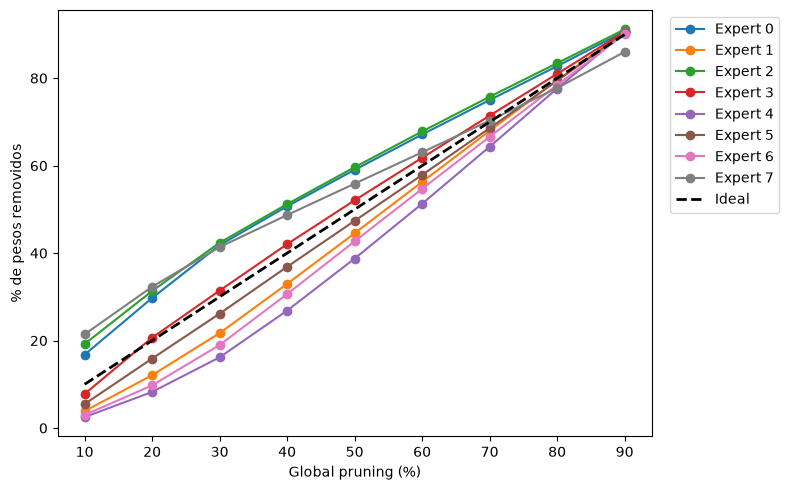

In [33]:
plot_pruning_curves(df_pruning1)

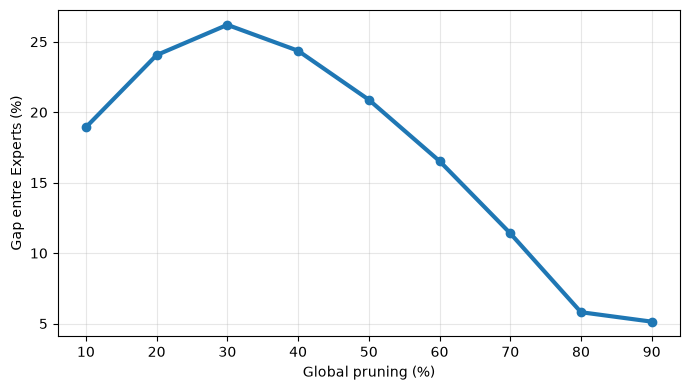

In [38]:
plot_gap(df_pruning1)

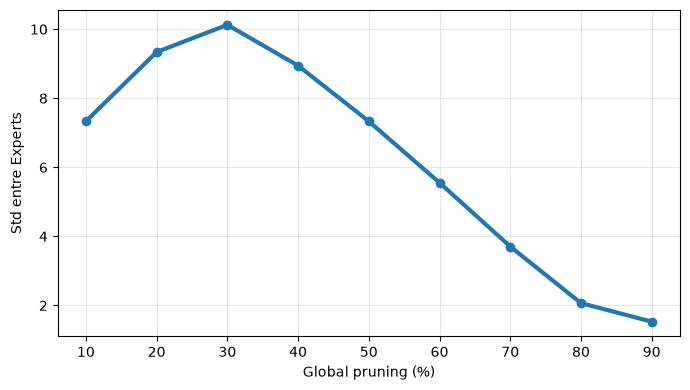

In [39]:
plot_std(df_pruning1)

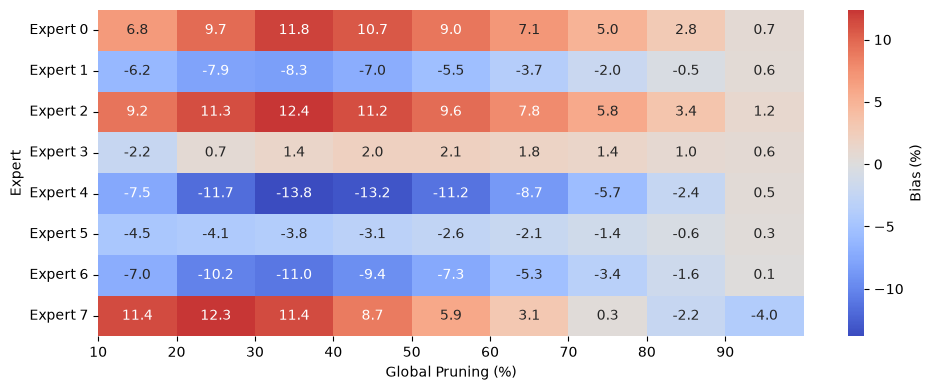

In [44]:
plot_bias_heatmap(bias_df1)

## Simulação modelo 2

In [26]:
df_pruning2 = simulate_global_pruning(model2)

df_pruning2

,Global Pruning (%),Threshold,Expert 0,Expert 1,Expert 2,Expert 3,Expert 4,Expert 5,Expert 6,Expert 7,Min Expert,Max Expert,Gap,Std Experts
0,10,1.114575e-23,2.272272,10.675287,18.086243,13.502932,10.366154,9.513521,7.254601,8.329010,2.272272,18.086243,15.813971,4.308883
1,20,5.824551e-11,4.404402,20.237017,29.606152,26.320124,22.723913,20.396566,17.385101,18.926764,4.404402,29.606152,25.201750,6.991669
2,30,3.843113e-04,10.539532,30.444574,39.663696,35.498333,33.177423,31.491423,29.517889,29.667139,10.539532,39.663696,29.124165,8.024881
3,40,2.364420e-03,20.297050,41.209745,49.014330,44.619989,43.423319,40.557766,41.457939,39.419889,20.297050,49.014330,28.717279,7.958992
4,50,5.128299e-03,33.023262,51.457071,57.668018,53.433418,53.121567,50.042391,52.572632,48.681688,33.023262,57.668018,24.644756,6.883149
5,60,1.073570e-02,47.329426,61.991882,65.786362,62.084818,62.089157,59.089756,62.960148,58.668470,47.329426,65.786362,18.456936,5.220968
6,70,1.828002e-02,61.336803,72.008944,74.224806,71.040297,71.386242,68.412256,72.785568,68.805075,61.336803,74.224806,12.888002,3.735771
7,80,2.803939e-02,74.917555,81.671143,82.705736,80.481768,81.078529,78.116369,82.118750,78.910160,74.917555,82.705736,7.788181,2.412603
8,90,4.258067e-02,88.046932,91.098022,91.135168,90.462351,91.060019,88.101625,91.023254,89.072609,88.046932,91.135168,3.088236,1.282433


In [29]:
bias_df2 = analyze_pruning_bias(df_pruning2)

bias_df2

,Global Pruning (%),Expert 0,Expert 1,Expert 2,Expert 3,Expert 4,Expert 5,Expert 6,Expert 7,Mean Bias,Std Bias,Max Bias,Min Bias
0,10,-7.727728,0.675287,8.086243,3.502932,0.366154,-0.486479,-2.745399,-1.670990,0.000002,4.606390,8.086243,-7.727728
1,20,-15.595598,0.237017,9.606152,6.320124,2.723913,0.396566,-2.614899,-1.073236,0.000005,7.474408,9.606152,-15.595598
2,30,-19.460468,0.444574,9.663696,5.498333,3.177423,1.491423,-0.482111,-0.332861,0.000001,8.578959,9.663696,-19.460468
3,40,-19.702950,1.209745,9.014330,4.619989,3.423319,0.557766,1.457939,-0.580111,0.000004,8.508521,9.014330,-19.702950
4,50,-16.976738,1.457071,7.668018,3.433418,3.121567,0.042391,2.572632,-1.318312,0.000006,7.358396,7.668018,-16.976738
5,60,-12.670574,1.991882,5.786362,2.084818,2.089157,-0.910244,2.960148,-1.331530,0.000002,5.581450,5.786362,-12.670574
6,70,-8.663197,2.008944,4.224806,1.040297,1.386242,-1.587744,2.785568,-1.194925,-0.000001,3.993707,4.224806,-8.663197
7,80,-5.082445,1.671143,2.705736,0.481768,1.078529,-1.883631,2.118750,-1.089840,0.000001,2.579181,2.705736,-5.082445
8,90,-1.953068,1.098022,1.135168,0.462351,1.060019,-1.898375,1.023254,-0.927391,-0.000002,1.370978,1.135168,-1.953068


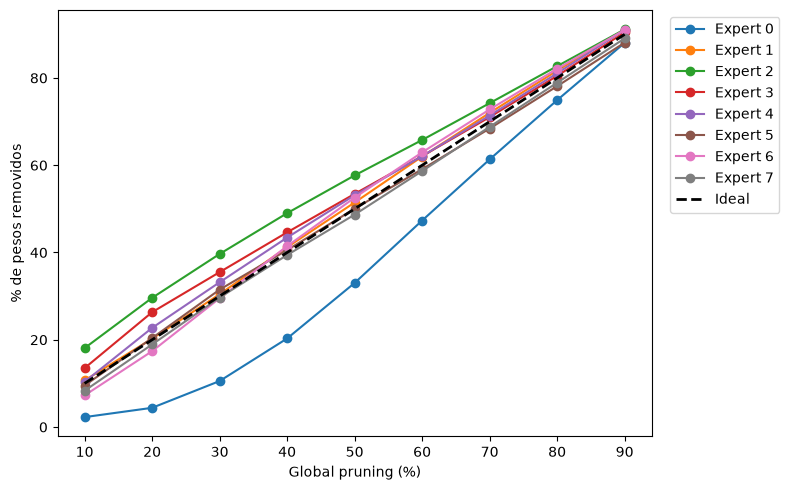

In [34]:
plot_pruning_curves(df_pruning2)

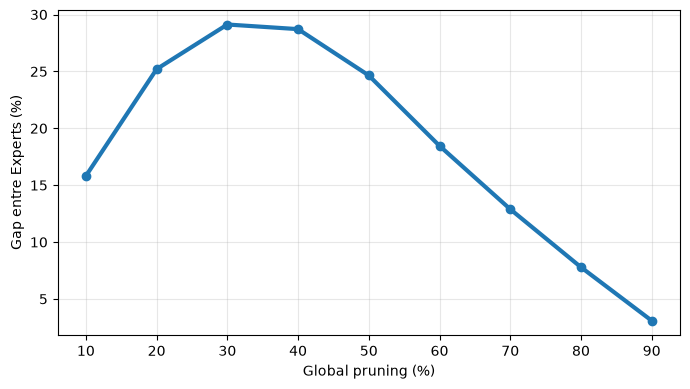

In [40]:
plot_gap(df_pruning2)

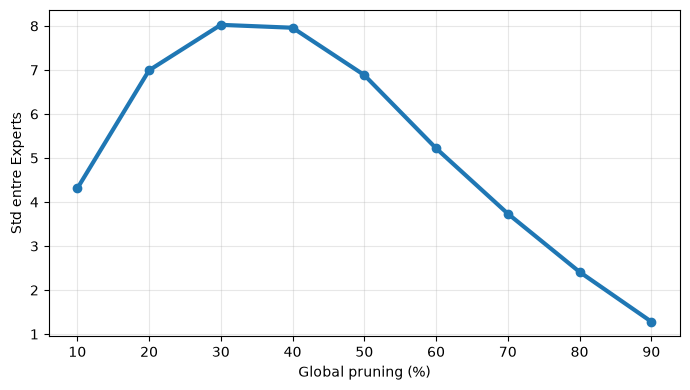

In [41]:
plot_std(df_pruning2)

comparativos dos modelos

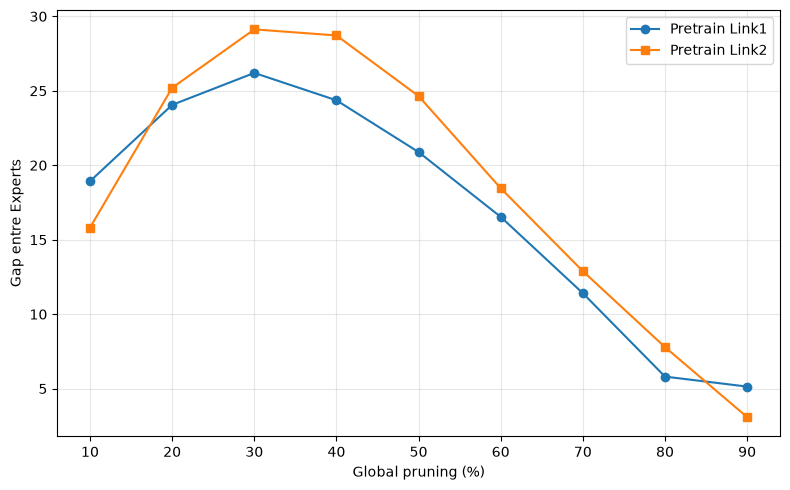

In [42]:
compare_models(df_pruning1, df_pruning2)

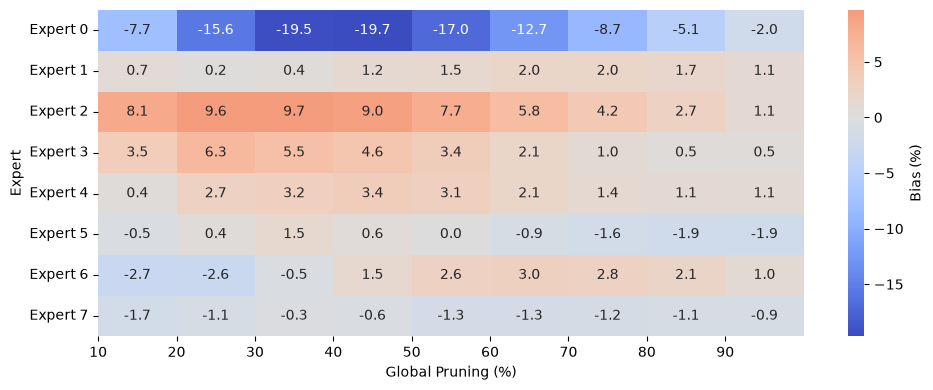

In [45]:
plot_bias_heatmap(bias_df2)